# 03 – Stage 1 Triad Analysis

Full empirical analysis for the **base / similar / dissimilar** triad:

1. Return-distribution signatures (heavy tails, QQ, power-law fits)
2. Volatility clustering (ACF, Ljung-Box, burst detection)
3. Reversal / overshoot (conditional returns after large moves)
4. Liquidity & activity regressions (bin stratification, OLS, deadline effects)
5. Cross-triad summary table

In [1]:
import sys, pathlib, logging, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
logging.basicConfig(level=logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=0.9)

from src.config import DATA_PROCESSED, TRIAD_MARKETS

from src.analyze.return_distribution import (
    cross_triad_stats,
    cross_triad_tail_table,
    plot_return_histograms,
    plot_qq,
    plot_tail_ccdf,
)
from src.analyze.volatility import (
    ljung_box_test,
    detect_bursts,
    burst_summary,
    plot_acf_panels,
    plot_acf_overlay,
    plot_rolling_vol_with_price,
)
from src.analyze.reversal import (
    cross_triad_reversal_table,
    plot_conditional_returns,
)
from src.analyze.liquidity_regression import (
    bin_stratification,
    ols_volatility_activity,
    ols_volatility_spread,
    plot_bin_stratification,
    plot_deadline_effect,
)

In [2]:
# Load per-market feature tables
dfs: dict[str, pd.DataFrame] = {}
for m in TRIAD_MARKETS:
    slug = m["slug"]
    p = DATA_PROCESSED / f"features_{slug}.parquet"
    if p.exists():
        dfs[slug] = pd.read_parquet(p)
        print(f"  {m['role']:12s} {slug:40s} {len(dfs[slug]):>6d} rows")
    else:
        print(f"  {m['role']:12s} {slug:40s} NOT FOUND")

# Stacked DataFrame for regressions
all_path = DATA_PROCESSED / "features_all.parquet"
df_all = pd.read_parquet(all_path) if all_path.exists() else pd.concat(dfs.values(), ignore_index=True)

  base         will-vivek-ramaswamy-win-the-2028-republican-presidential-nomination    741 rows
  similar      will-delcy-rodrguez-be-the-leader-of-venezuela-end-of-2026    706 rows
  dissimilar   nba-2025-26-clutch-player-of-the-year-jimmy-butler    742 rows


---
## 1. Return-Distribution Signatures

### 1a. Summary statistics

In [3]:
stats_table = cross_triad_stats(dfs)
stats_table.round(4)

,n,mean,std,skewness,kurtosis,min,max,jarque_bera_stat,jarque_bera_p,role
market_slug,,,,,,,,,,
will-vivek-ramaswamy-win-the-2028-republican-presidential-nomination,740,0.0004,0.0122,-1.4068,174.2748,-0.2037,0.1724,936705.4072,0.0,base
will-delcy-rodrguez-be-the-leader-of-venezuela-end-of-2026,705,0.0008,0.0177,-0.0756,17.6682,-0.1215,0.1416,9170.4843,0.0,similar
nba-2025-26-clutch-player-of-the-year-jimmy-butler,741,0.0000,0.0306,2.3135,84.1968,-0.3582,0.3582,219536.7924,0.0,dissimilar


### 1b. Histograms with normal overlay

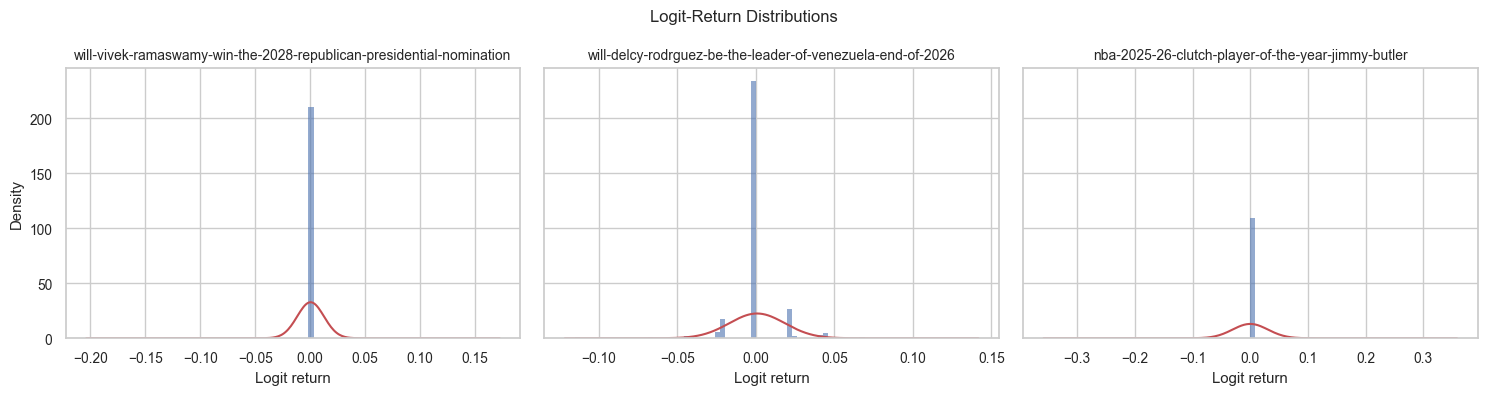

In [4]:
fig = plot_return_histograms(dfs)
plt.show()

### 1c. QQ plots vs. Normal

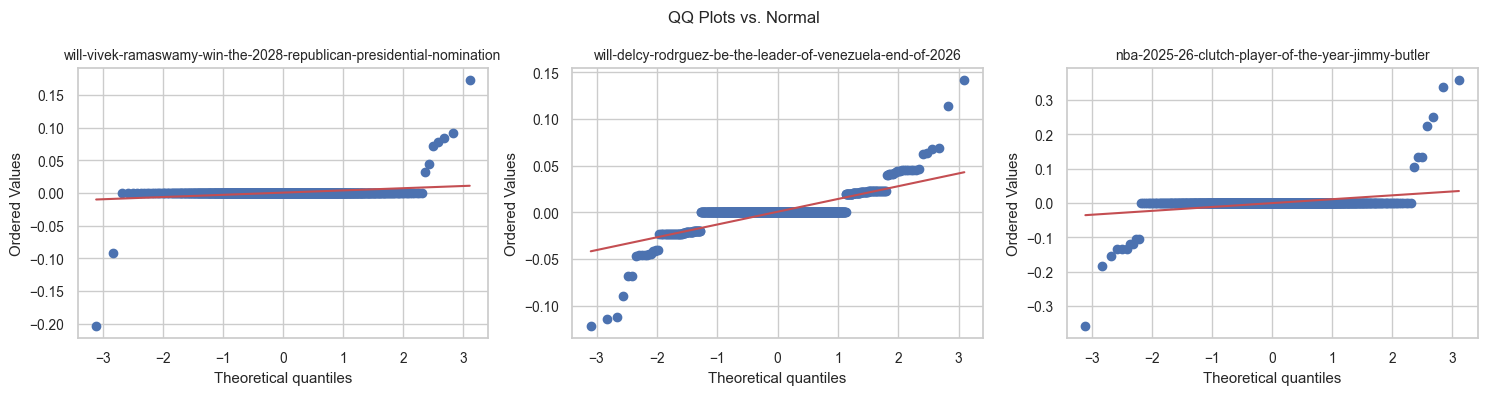

In [5]:
fig = plot_qq(dfs)
plt.show()

### 1d. Complementary CDF (log-log)

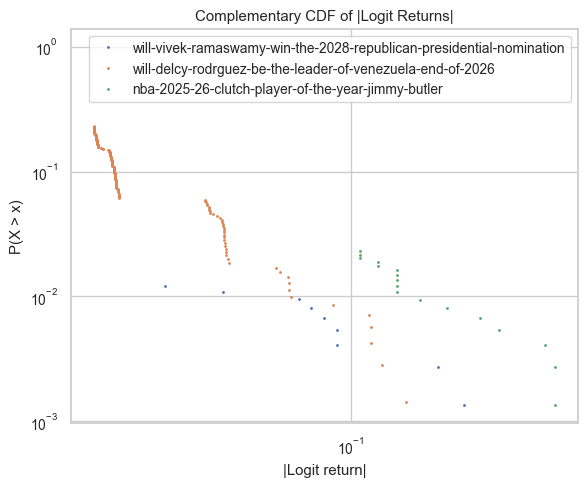

In [6]:
fig = plot_tail_ccdf(dfs)
plt.show()

### 1e. Power-law tail fitting

In [7]:
try:
    tail_table = cross_triad_tail_table(dfs)
    display(tail_table.round(4))
except ImportError:
    print("Install the `powerlaw` package to run tail fits.")

/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Project/venv/lib/python3.13/site-packages/powerlaw/fitting.py:528: UserWarning: No valid values for xmin found.
  warnings.warn('No valid values for xmin found.')
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Project/venv/lib/python3.13/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Project/venv/lib/python3.13/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


,alpha,xmin,R_vs_lognormal,p_vs_lognormal,R_vs_exponential,p_vs_exponential
market_slug,,,,,,
will-vivek-ramaswamy-win-the-2028-republican-presidential-nomination,2.3457,0.0450,-1.2847,0.3327,-1.2566,0.1381
will-delcy-rodrguez-be-the-leader-of-venezuela-end-of-2026,2.9049,0.0229,-0.1757,0.7429,3.2056,0.3815
nba-2025-26-clutch-player-of-the-year-jimmy-butler,3.0000,0.1059,-0.1387,0.6738,0.5266,0.5456


---
## 2. Volatility Clustering

### 2a. ACF of |r_t| (per-market panels)

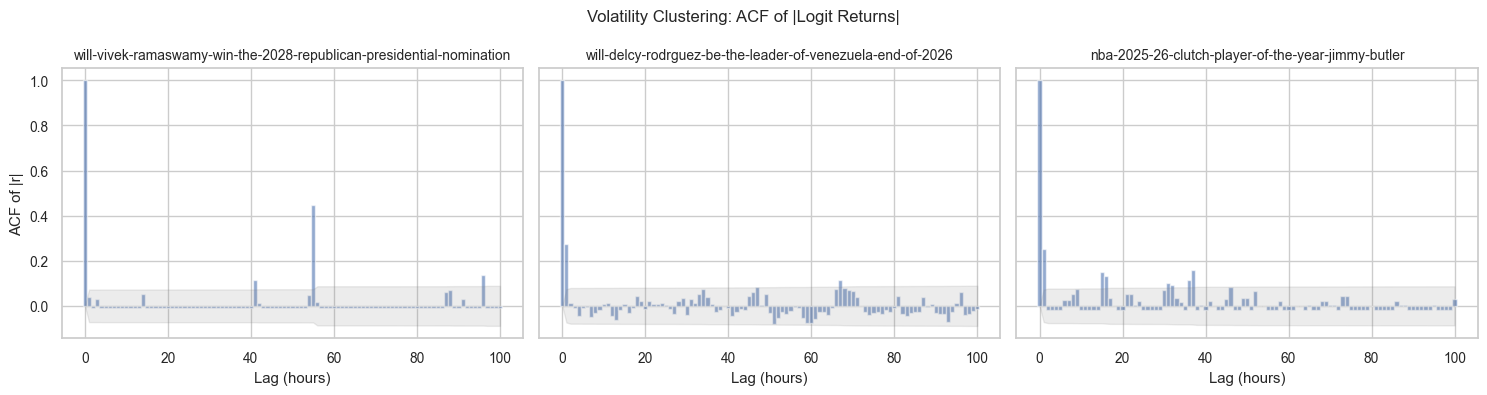

In [8]:
fig = plot_acf_panels(dfs)
plt.show()

### 2b. ACF overlay (cross-triad comparison)

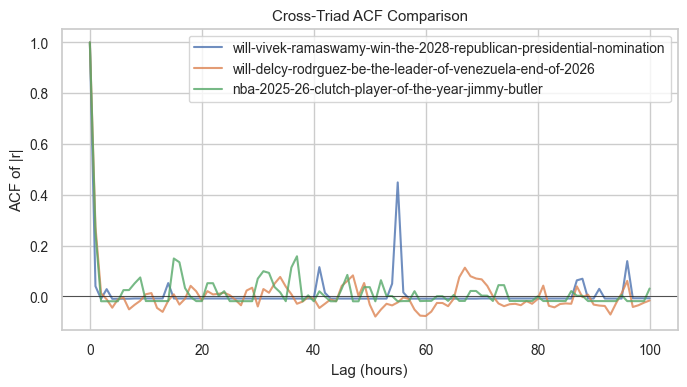

In [9]:
fig = plot_acf_overlay(dfs)
plt.show()

### 2c. Ljung-Box tests

In [10]:
for slug, df in dfs.items():
    print(f"\n── {slug} ──")
    lb = ljung_box_test(df)
    display(lb)


── will-vivek-ramaswamy-win-the-2028-republican-presidential-nomination ──


,lag,lb_stat,lb_pvalue
0,10,2.275189,0.993763
1,20,4.811239,0.999795
2,50,16.957999,0.999997



── will-delcy-rodrguez-be-the-leader-of-venezuela-end-of-2026 ──


,lag,lb_stat,lb_pvalue
0,10,58.063582,8.409666e-09
1,20,65.133608,1.111230e-06
2,50,93.125654,2.068237e-04



── nba-2025-26-clutch-player-of-the-year-jimmy-butler ──


,lag,lb_stat,lb_pvalue
0,10,55.906511,2.137365e-08
1,20,88.918148,1.145200e-10
2,50,154.624463,1.279163e-12


### 2d. Rolling volatility & burst episodes

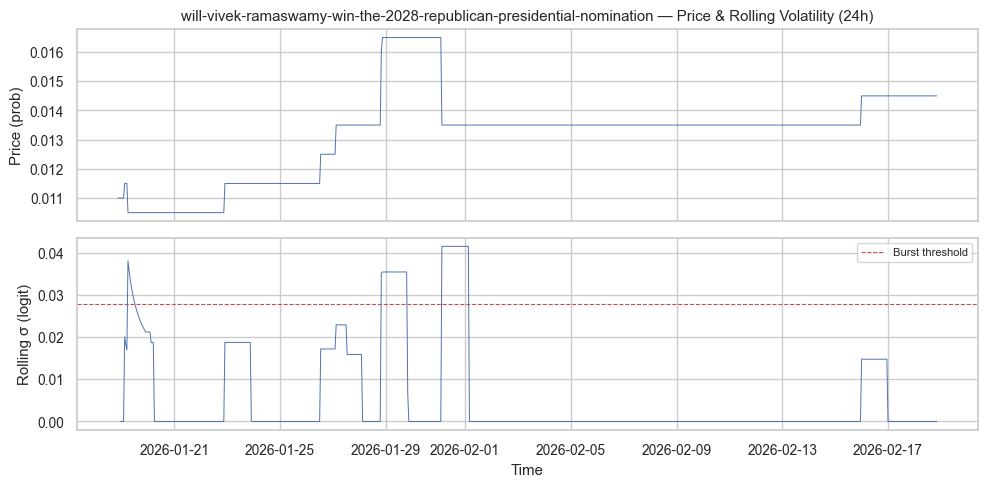

will-vivek-ramaswamy-win-the-2028-republican-presidential-nomination: {'n_bursts': 3, 'mean_duration_h': np.float64(18.333333333333332), 'mean_intensity': np.float64(0.03654104761576105)}


,start,end,duration_hours,mean_vol
0,2026-01-19 06:00:14+00:00,2026-01-19 12:00:16+00:00,7,0.032554
1,2026-01-28 20:00:17+00:00,2026-01-29 19:00:16+00:00,24,0.035486
2,2026-01-31 03:00:18+00:00,2026-02-01 03:00:18+00:00,24,0.041583


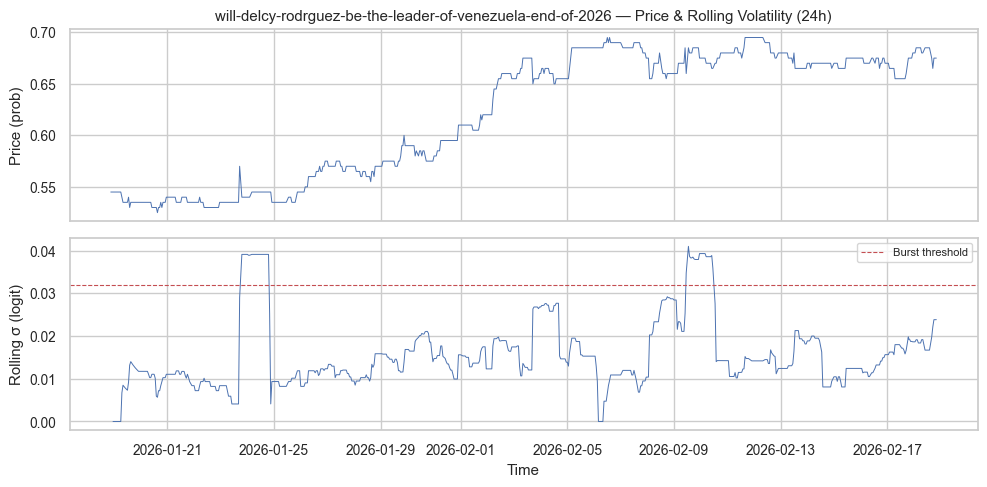

will-delcy-rodrguez-be-the-leader-of-venezuela-end-of-2026: {'n_bursts': 2, 'mean_duration_h': np.float64(23.5), 'mean_intensity': np.float64(0.03875487230694448)}


,start,end,duration_hours,mean_vol
0,2026-01-23 19:00:26+00:00,2026-01-24 19:00:27+00:00,23,0.039081
1,2026-02-09 11:00:24+00:00,2026-02-10 11:00:27+00:00,24,0.038429


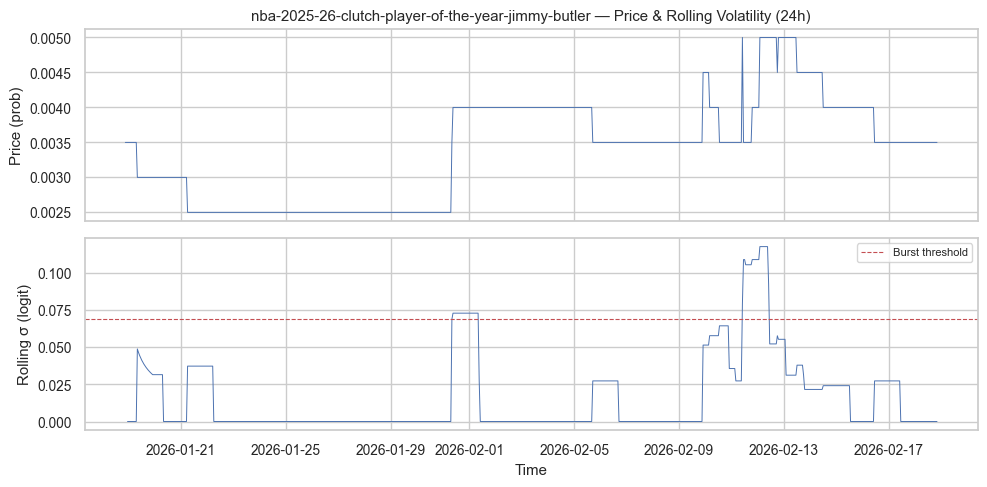

nba-2025-26-clutch-player-of-the-year-jimmy-butler: {'n_bursts': 2, 'mean_duration_h': np.float64(24.0), 'mean_intensity': np.float64(0.0911060116910353)}


,start,end,duration_hours,mean_vol
0,2026-01-31 09:00:39+00:00,2026-02-01 08:00:18+00:00,23,0.073007
1,2026-02-11 10:00:18+00:00,2026-02-12 10:00:24+00:00,25,0.109205


In [11]:
for slug, df in dfs.items():
    fig = plot_rolling_vol_with_price(df, slug)
    plt.show()

    bursts = detect_bursts(df)
    summary = burst_summary(bursts)
    print(f"{slug}: {summary}")
    if not bursts.empty:
        display(bursts.head(10))

---
## 3. Reversal / Overshoot Analysis

### 3a. Conditional return paths

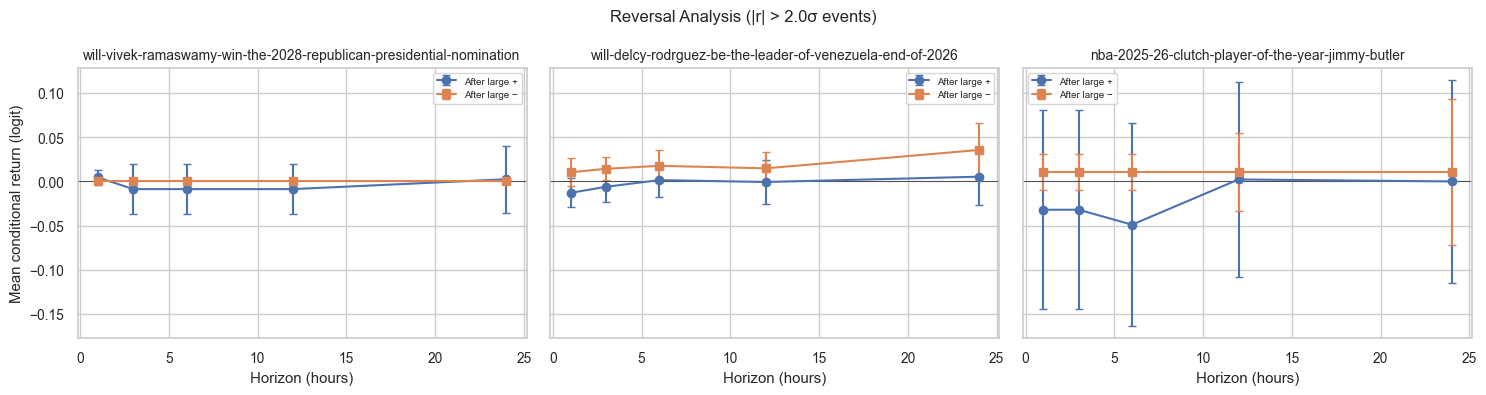

In [12]:
fig = plot_conditional_returns(dfs)
plt.show()

### 3b. Conditional return tables

In [13]:
reversal_tables = cross_triad_reversal_table(dfs)
for slug, tbl in reversal_tables.items():
    print(f"\n── {slug} ──")
    display(tbl.round(4))


── will-vivek-ramaswamy-win-the-2028-republican-presidential-nomination ──


,mean_after_pos,se_after_pos,n_pos,tstat_pos,pval_pos,mean_after_neg,se_after_neg,n_neg,tstat_neg,pval_neg
horizon,,,,,,,,,,
1,0.0045,0.0045,7,1.0000,0.3559,0.0,0.0,2,NaN,NaN
3,-0.0087,0.0146,7,-0.5953,0.5734,0.0,0.0,2,NaN,NaN
6,-0.0087,0.0146,7,-0.5953,0.5734,0.0,0.0,2,NaN,NaN
12,-0.0087,0.0146,7,-0.5953,0.5734,0.0,0.0,2,NaN,NaN
24,0.0025,0.0192,7,0.1285,0.9019,0.0,0.0,2,NaN,NaN



── will-delcy-rodrguez-be-the-leader-of-venezuela-end-of-2026 ──


,mean_after_pos,se_after_pos,n_pos,tstat_pos,pval_pos,mean_after_neg,se_after_neg,n_neg,tstat_neg,pval_neg
horizon,,,,,,,,,,
1,-0.0129,0.0083,25,-1.5504,0.1341,0.0104,0.0080,17,1.2947,0.2138
3,-0.0060,0.0088,24,-0.6865,0.4993,0.0143,0.0067,17,2.1374,0.0484
6,0.0015,0.0100,24,0.1508,0.8815,0.0177,0.0091,15,1.9354,0.0734
12,-0.0006,0.0128,24,-0.0500,0.9605,0.0148,0.0096,15,1.5394,0.1460
24,0.0054,0.0161,23,0.3331,0.7422,0.0356,0.0153,15,2.3224,0.0358



── nba-2025-26-clutch-player-of-the-year-jimmy-butler ──


,mean_after_pos,se_after_pos,n_pos,tstat_pos,pval_pos,mean_after_neg,se_after_neg,n_neg,tstat_neg,pval_neg
horizon,,,,,,,,,,
1,-0.0320,0.0575,7,-0.5565,0.5980,0.0106,0.0106,10,1.0000,0.3434
3,-0.0320,0.0575,7,-0.5565,0.5980,0.0106,0.0106,10,1.0000,0.3434
6,-0.0489,0.0585,7,-0.8369,0.4347,0.0106,0.0106,10,1.0000,0.3434
12,0.0022,0.0561,7,0.0401,0.9693,0.0106,0.0226,10,0.4682,0.6508
24,0.0000,0.0584,7,0.0000,1.0000,0.0106,0.0420,10,0.2518,0.8069


---
## 4. Liquidity & Activity Regressions

### 4a. Trade-rate bin stratification

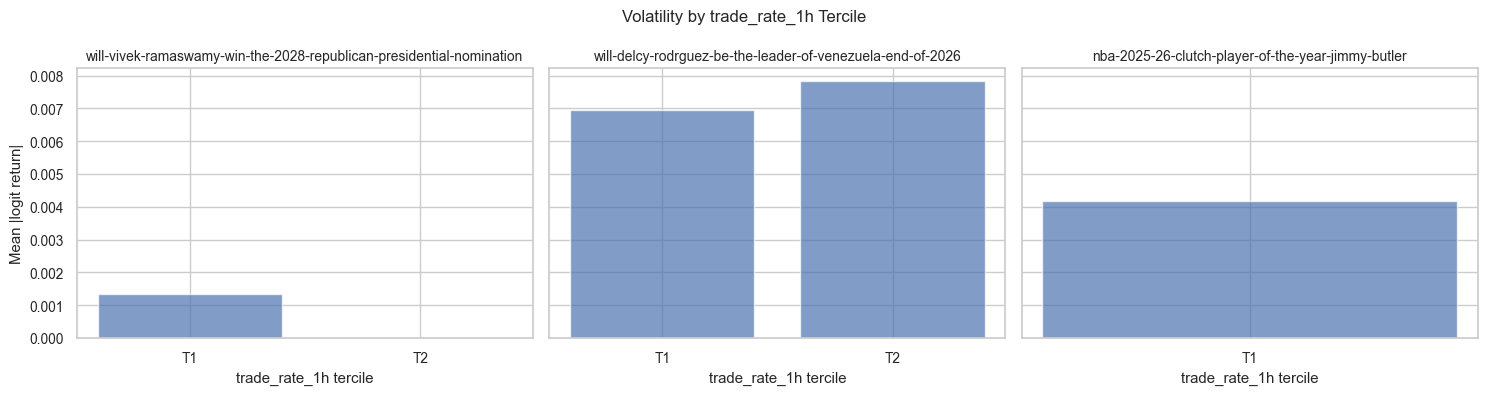


── will-vivek-ramaswamy-win-the-2028-republican-presidential-nomination ──


,bin,trade_rate_1h_lo,trade_rate_1h_hi,mean_abs_r,kurtosis,acf1_abs_r,n
0,0,0,2,0.0013,154.6851,0.039,653
1,1,3,68,0.0000,0.0000,NaN,87



── will-delcy-rodrguez-be-the-leader-of-venezuela-end-of-2026 ──


,bin,trade_rate_1h_lo,trade_rate_1h_hi,mean_abs_r,kurtosis,acf1_abs_r,n
0,0,0,3,0.0070,19.0917,0.1707,606
1,1,4,42,0.0078,12.5494,0.2603,99



── nba-2025-26-clutch-player-of-the-year-jimmy-butler ──


,bin,trade_rate_1h_lo,trade_rate_1h_hi,mean_abs_r,kurtosis,acf1_abs_r,n
0,0,0,5,0.0042,84.7758,0.2526,741


In [14]:
fig = plot_bin_stratification(dfs, bin_col="trade_rate_1h")
plt.show()

for slug, df in dfs.items():
    print(f"\n── {slug} ──")
    display(bin_stratification(df, "trade_rate_1h").round(4))

### 4b. OLS: |r| ~ trade_rate + time_to_resolution

In [15]:
try:
    model_act = ols_volatility_activity(df_all)
    print(model_act.summary())
except Exception as e:
    print(f"Regression failed: {e}")

                            OLS Regression Results                            
Dep. Variable:       abs_logit_return   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     15.50
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           1.66e-12
Time:                        15:19:44   Log-Likelihood:                 5332.3
No. Observations:                2186   AIC:                        -1.065e+04
Df Residuals:                    2181   BIC:                        -1.063e+04
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0818      0

### 4c. OLS: |r| ~ spread + time_to_resolution

In [16]:
try:
    model_spread = ols_volatility_spread(df_all)
    print(model_spread.summary())
except Exception as e:
    print(f"Regression failed: {e}")

                            OLS Regression Results                            
Dep. Variable:       abs_logit_return   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     30.74
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           6.83e-14
Time:                        15:19:46   Log-Likelihood:                 5331.2
No. Observations:                2186   AIC:                        -1.066e+04
Df Residuals:                    2183   BIC:                        -1.064e+04
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.2009      0

### 4d. Deadline effect plot

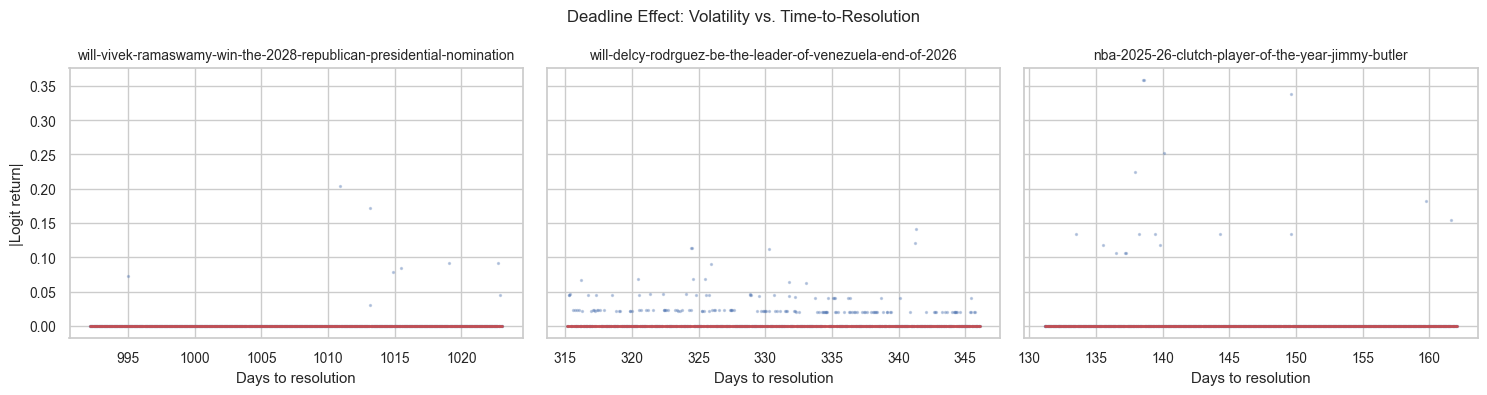

In [17]:
fig = plot_deadline_effect(dfs)
plt.show()

---
## 5. Cross-Triad Summary Table

One table combining all key signatures to directly compare the three
markets and assess whether dynamics generalise across categories.

In [18]:
from src.analyze.volatility import abs_return_acf

rows = []
for slug, df in dfs.items():
    role = df["role"].iloc[0] if "role" in df.columns else ""
    r = df["logit_return"].dropna()
    ar = df["abs_logit_return"].dropna()

    acf_vals = abs_return_acf(df, nlags=10)

    bursts = detect_bursts(df)
    bs = burst_summary(bursts)

    reversal = cross_triad_reversal_table({slug: df})
    rev_h3 = reversal[slug].loc[3, "mean_after_neg"] if 3 in reversal[slug].index else np.nan

    spread_val = df["spread"].iloc[0] if "spread" in df.columns and df["spread"].notna().any() else np.nan

    rows.append({
        "Market": slug,
        "Role": role,
        "N": len(r),
        "Kurtosis": float(r.kurtosis()),
        "ACF(1) |r|": float(acf_vals.loc[1, "acf"]) if len(acf_vals) > 1 else np.nan,
        "ACF(10) |r|": float(acf_vals.loc[10, "acf"]) if len(acf_vals) > 10 else np.nan,
        "Burst count": bs["n_bursts"],
        "Mean burst dur (h)": round(bs["mean_duration_h"], 1),
        "Mean reversion (h=3)": round(rev_h3, 6) if not np.isnan(rev_h3) else np.nan,
        "Spread": spread_val,
    })

summary = pd.DataFrame(rows).set_index("Market")
summary

,Role,N,Kurtosis,ACF(1) |r|,ACF(10) |r|,Burst count,Mean burst dur (h),Mean reversion (h=3),Spread
Market,,,,,,,,,
will-vivek-ramaswamy-win-the-2028-republican-presidential-nomination,base,740,175.466275,0.040215,-0.008089,3,18.3,0.000000,0.998
will-delcy-rodrguez-be-the-leader-of-venezuela-end-of-2026,similar,705,17.802667,0.274746,0.008550,2,23.5,0.014273,0.980
nba-2025-26-clutch-player-of-the-year-jimmy-butler,dissimilar,741,84.775800,0.252573,-0.018275,2,24.0,0.010586,0.998


### Interpretation

Compare the rows above:

- **If signatures are similar across base, similar, AND dissimilar** →
  dynamics are platform-wide → justifies pooling in Stage 2.
- **If the dissimilar market diverges** → dynamics are niche-specific →
  Stage 2 should focus on a single topic cluster.